# Business Problem 

#### Many companies receive vendor invoices after goods are delivered. Sometimes the freight charges on these invoices are higher or lower than expected, making it difficult to verify whether the charges are reasonable. Manually checking every invoice is time-consuming and inefficient.

#### The goal is to build a regression model that predicts the freight cost based on invoice information (such as order value/dollars). Accurate predictions help the company estimate shipping expenses in advance and make better business decisions.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# **Predicting Freight Cost**

**Objective:** Build a machine learning model to estimate the freight (shipping) cost of vendor invoices before they are processed.

* Freight cost is an important part of the total purchase cost.
* Unexpected freight charges can increase business expenses.
* Accurate freight cost prediction helps companies plan budgets and control costs.
* This helps purchasing and finance teams identify unusual shipping costs and make better decisions.


In [5]:
conn= sqlite3.connect("C:/Users/Dell/Desktop/ML/Vendor invoice intelligence system/data/inventory.db")
tables= pd.read_sql_query(" select name from sqlite_master where type='table'", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [6]:
for table in tables['name']:
    print(f'Table : {table}')
    df= pd.read_sql_query(f"select * from {table} limit  5", conn)
    display(df)

Table : purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table : purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table : vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table : begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table : end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
vendor_df= pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


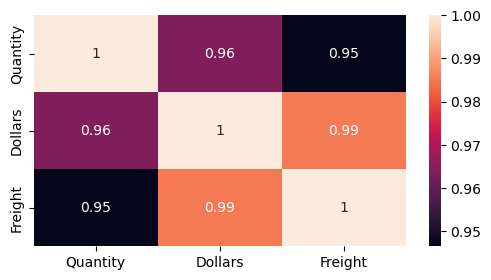

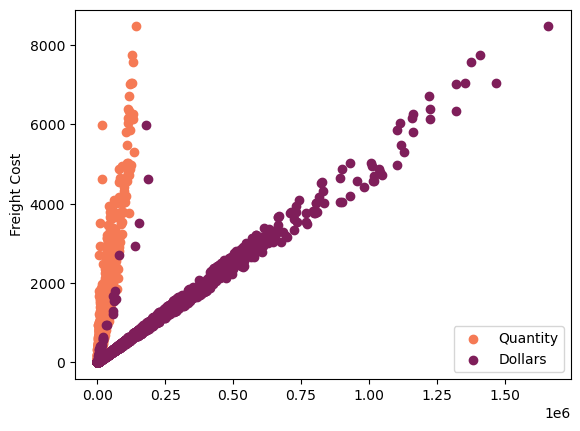

In [8]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(6,3))
sns.heatmap(
    vendor_df[['Quantity', 'Dollars', 'Freight']].corr(),
    annot=True
)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1e5a')

plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [9]:
vendor_df['freight_per_unit']= vendor_df['Freight'] / vendor_df['Quantity'] 
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


# **Freight Cost Analysis by Order Quantity**

In [11]:
low_quantity= vendor_df['Quantity'].quantile(0.25)
low_quantity

83.0

In [12]:
high_quantity= vendor_df['Quantity'].quantile(0.75)
high_quantity

5100.5

In [13]:
vendor_df.loc[ vendor_df['Quantity'] < low_quantity, 'freight_per_unit' ].mean()

0.09489854253138316

In [14]:
vendor_df.loc[ vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

0.049077654690759046

# Conclusion

### Objective
Analyze how freight cost per unit changes for low-quantity and high-quantity orders.

### Why?
Large orders often reduce the shipping cost per unit because transportation costs are spread across more items. This concept is known as **economies of scale**. And we not used total Freight, the comparison would not be fair because large orders naturally have higher total freight costs simply because they contain more items.

### Approach
- Calculate the 25th percentile (Low Quantity)
- Calculate the 75th percentile (High Quantity)
- Compare the average freight cost per unit for both groups

# **Creating Model and its Evaluation**

In [17]:
X= vendor_df[['Dollars']]
y= vendor_df['Freight']

In [18]:
from sklearn.model_selection import train_test_split

X_train ,X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


In [78]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth= 5),
    "Random Forest": RandomForestRegressor(max_depth= 4, random_state=42)
}

In [80]:
for name, model in models.items():

    model.fit(X_train,y_train)

    y_pred= model.predict(X_test)

    print(f"\n{name}")
    
    print('MAE:', mean_absolute_error(y_test,y_pred).round(2))
    print('RMSE:', root_mean_squared_error(y_test,y_pred).round(2) )
    print(f"R2 Score: { r2_score(y_test,y_pred) *100:.2f}%")


Linear Regression
MAE: 24.11
RMSE: 124.72
R2 Score: 96.99%

Decision Tree
MAE: 32.97
RMSE: 150.31
R2 Score: 95.63%

Random Forest
MAE: 30.31
RMSE: 130.66
R2 Score: 96.69%


# Model Comparison Summary

### Observations
- Linear Regression achieved the lowest prediction error.
- It also produced the highest R² score.
- This indicates a strong linear relationship between purchase amount and freight cost.

### Conclusion
Linear Regression was selected as the final model because it provides the most accurate and reliable freight cost predictions on the test data.